In [9]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd

X_TBM = pd.read_csv('data_A1/X_TBM.csv')
y_TBM = pd.read_csv('data_A1/y_TBM.csv')

In [12]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Train/test split & cross-validation ---
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# --- Tree-based models ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# XGBoost and LightGBM (install if not yet available: pip install xgboost lightgbm)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

# --- Feature importance / interpretability ---
from sklearn.inspection import permutation_importance

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Misc ---
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [13]:
# --- Basic shape check ---
print("X_TBM shape:", X_TBM.shape)
print("y_TBM shape:", y_TBM.shape)
print("\ny_TBM columns:", list(y_TBM.columns))

# --- Isolate main target ---
target_col = "Diagnosis"
y = y_TBM[target_col]

# --- Class balance ---
print("\nClass counts:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True).round(3))

X_TBM shape: (774, 82)
y_TBM shape: (774, 3)

y_TBM columns: ['Management', 'Severity', 'Diagnosis']

Class counts:
Diagnosis
1.0    458
0.0    316
Name: count, dtype: int64

Class proportions:
Diagnosis
1.0    0.592
0.0    0.408
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

X = X_TBM.copy()
y = y_TBM[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Positive rate:", y_train.mean().round(3))
print("Test shape:", X_test.shape, "| Positive rate:", y_test.mean().round(3))

Train shape: (619, 82) | Positive rate: 0.591
Test shape: (155, 82) | Positive rate: 0.594


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified CV, shuffled for randomness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Metrics we care about for a medical diagnosis task:
# - recall: catching actual appendicitis cases (minimize false negatives)
# - precision: avoid unnecessary interventions (minimize false positives)
# - f1: balance of both
# - roc_auc: overall discriminative ability
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [16]:
def evaluate_model_cv(model, X_train, y_train, cv, scoring, model_name="Model"):
    """
    Runs cross-validation for a given model and returns mean/std of each metric.
    Also returns the raw cv_results dict in case you want per-fold detail.
    """
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,   # lets us check overfitting (train vs val gap)
        n_jobs=-1
    )
    
    summary = {"model": model_name}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]
        summary[f"{metric}_val_mean"] = test_scores.mean()
        summary[f"{metric}_val_std"] = test_scores.std()
        summary[f"{metric}_train_mean"] = train_scores.mean()
    
    return pd.DataFrame([summary]), cv_results

In [17]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)

results_df, raw_cv = evaluate_model_cv(
    dt_baseline, X_train, y_train, cv, scoring, model_name="Decision Tree (baseline)"
)

results_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.928954,0.022386,1.0,0.9375,0.018553,1.0,0.942614,0.020155,1.0,0.940039,0.01911,1.0,0.925895,0.022929,1.0


In [18]:
# Fit an unconstrained tree to get the full pruning path
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of candidate alpha values: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.6f}")

Number of candidate alpha values: 23
Alpha range: 0.000000 to 0.138318


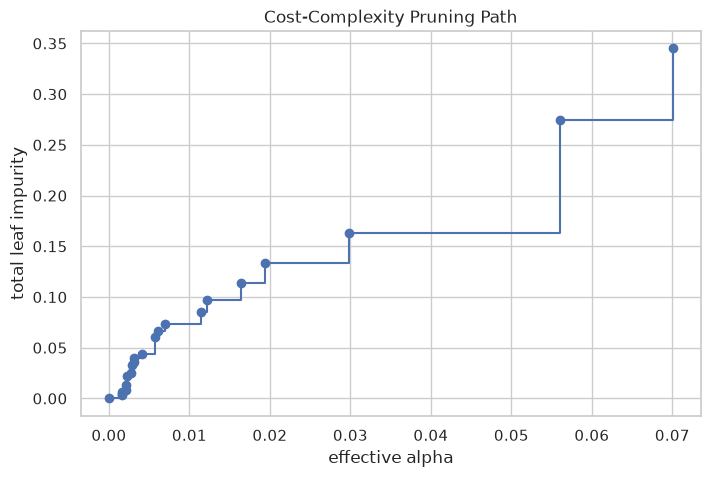

In [19]:
# Plot alpha vs. total impurity of leaves (helps visualize the tradeoff)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total leaf impurity")
ax.set_title("Cost-Complexity Pruning Path")
plt.show()

In [20]:
# For each candidate alpha, fit a tree and check its CV F1 score
# We skip the very last alpha (it prunes to a single-node tree, which is trivial)
from sklearn.model_selection import cross_val_score

alpha_results = []
for alpha in ccp_alphas[:-1]:
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring="f1")
    alpha_results.append({
        "ccp_alpha": alpha,
        "f1_val_mean": scores.mean(),
        "f1_val_std": scores.std(),
        "n_leaves": tree.fit(X_train, y_train).get_n_leaves()
    })

alpha_df = pd.DataFrame(alpha_results)
alpha_df.sort_values("f1_val_mean", ascending=False).head(10)

,ccp_alpha,f1_val_mean,f1_val_std,n_leaves
4,0.002154,0.941679,0.016375,26
5,0.002154,0.941679,0.016375,26
7,0.002769,0.941679,0.016375,21
8,0.002847,0.941679,0.016375,18
6,0.002271,0.941679,0.016375,22
9,0.003116,0.940243,0.015063,17
10,0.003157,0.940243,0.015063,16
3,0.001616,0.940039,0.019110,29
0,0.000000,0.940039,0.019110,33
1,0.001603,0.940039,0.019110,31


### What this tells us:
- The best F1 (0.9417) is achieved by several ccp_alpha values between ~0.0022 and 0.0028, producing trees with 18-26 leaves.
- Compare to the baseline: unpruned tree (ccp_alpha=0, row index 0) had 33 leaves and F1 = 0.9400
- So pruning down to ~ 18-26 leaves gives a small but real F1 improvement, while using a noticeably simpler tree. That's a good sign - it means some of those extra splits in the unpruned tree were indeed just noise-fitting, not signal.
- A useful range for ccp_alpha in the grid search: roughly 0.0015 to 0.0035 captures the good performers here.

In [21]:
from sklearn.model_selection import GridSearchCV

# Narrowed-down parameter grid, informed by what we just saw
param_grid = {
    "max_depth": [3, 5, 7,9, 10, 11,12,13,14,15,16,17,18,None ],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.0015, 0.002, 0.0025, 0.003, 0.0035]
}

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",          # optimize for F1 (balances precision/recall)
    cv=cv,                 # same StratifiedKFold as before, for consistency
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

dt_grid_search.fit(X_train, y_train)

print("Best params:", dt_grid_search.best_params_)
print("Best CV F1:", dt_grid_search.best_score_)

Fitting 5 folds for each of 1344 candidates, totalling 6720 fits
Best params: {'ccp_alpha': 0.002, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.9416785898405042


In [22]:
best_dt = dt_grid_search.best_estimator_

results_df, raw_cv = evaluate_model_cv(
    best_dt, X_train, y_train, cv, scoring, model_name="Decision Tree (tuned)"
)

results_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (tuned),0.930566,0.019405,0.995962,0.935384,0.017731,0.995252,0.948093,0.015953,0.997952,0.941679,0.016375,0.996595,0.926009,0.021063,0.998806


## Random Forest — Baseline

Random Forest builds many decision trees on bootstrapped samples of the training data,
each tree also considering only a random subset of features at each split. Predictions
are aggregated (majority vote for classification). This reduces variance compared to a
single tree, since errors from individual overfit trees tend to average out.

We start with a baseline (mostly default parameters) to get a reference point before tuning.

In [23]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,       # number of trees in the forest
    random_state=RANDOM_STATE,
    n_jobs=-1                # use all CPU cores
)

results_rf_baseline, raw_cv_rf = evaluate_model_cv(
    rf_baseline, X_train, y_train, cv, scoring, model_name="Random Forest (baseline)"
)

results_rf_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Random Forest (baseline),0.938618,0.018081,1.0,0.953544,0.024123,1.0,0.942577,0.01043,1.0,0.947897,0.014879,1.0,0.987231,0.004792,1.0


In [24]:
comparison_df = pd.concat([results_df, results_rf_baseline], ignore_index=True)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (tuned),0.930566,0.019405,0.995962,0.935384,0.017731,0.995252,0.948093,0.015953,0.997952,0.941679,0.016375,0.996595,0.926009,0.021063,0.998806
1,Random Forest (baseline),0.938618,0.018081,1.000000,0.953544,0.024123,1.000000,0.942577,0.010430,1.000000,0.947897,0.014879,1.000000,0.987231,0.004792,1.000000


## Interpreting Random Forest baseline vs. tuned Decision Tree

Random Forest improves on most metrics:
- f1_val_mean: 0.9417 -> 0.9479
- roc_auc_val_mean: 0.9260 -> 0.9872 (biggest jump)
- roc_auc_val_std: 0.0211 -> 0.0048 (much more stable across folds)

Train scores are all back to 1.0 (as expected -- each individual tree in the forest
still overfits its bootstrap sample), but this doesn't hurt val performance the way
it did for the single tree. This is exactly the variance-reduction effect bagging
is designed to produce.

The roc_auc jump is worth noting separately: roc_auc measures ranking quality across
all classification thresholds, not just the default 0.5 cutoff. A big roc_auc gain
with a smaller f1 gain suggests the forest is much better at *ranking* patients by
risk, even if the default threshold isn't optimally tuned yet -- something to keep
in mind if your group later wants to adjust the decision threshold (e.g. to prioritize
recall).

## Random Forest hyperparameters

Random Forest adds new hyperparameters on top of the Decision Tree ones we already know
(`max_depth`, `min_samples_split`, `min_samples_leaf`):

- **n_estimators**: number of trees in the forest. More trees generally reduce variance
  and stabilize predictions, with diminishing returns past a certain point (and rising
  compute cost). Rarely causes overfitting by itself -- unlike tree depth, adding more
  trees does not make the *ensemble* more prone to memorizing training data.

- **max_features**: number of features considered at each split, chosen randomly per split.
  This is what decorrelates the trees -- if every tree could see all features, they'd tend
  to make similar splits on the strongest predictors and end up highly correlated (which
  would defeat the variance-reduction benefit of averaging). Common choices: "sqrt"
  (default for classification, uses sqrt(n_features) per split), "log2", or a float
  (fraction of features), or an int (fixed number of features).

- **max_samples**: if bootstrap=True (default), this controls what fraction of the training
  set each tree is built on (default is the full dataset size, sampled with replacement).
  Lowering it increases diversity between trees (more variance reduction) but each tree
  sees less data.

- **bootstrap**: whether trees are built on bootstrap samples (True, default) or the full
  dataset (False). Almost always left True -- it's what makes "bagging" bagging.

We'll reuse max_depth, min_samples_split, min_samples_leaf, and ccp_alpha from before,
now combined with n_estimators and max_features.

## Random Forest — Randomized Search

A full grid search here would be expensive: Random Forest fits are much slower than a
single Decision Tree (n_estimators trees per fit), and we now have 6 hyperparameters
instead of 4. We use RandomizedSearchCV instead, which samples a fixed number of
random combinations rather than trying every combination exhaustively.

In [25]:
from scipy.stats import randint

param_dist_rf = {
    "n_estimators": randint(100, 600),
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=100,             # number of random combinations to try
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Best params:", rf_random_search.best_params_)
print("Best CV F1:", rf_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/home/magic_m/Schreibtisch/1_informatik/1_01_studium/26_SS/Data-Project-ML/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/magic_m/Schreibtisch/1_informatik/1_01_studium/26_SS/Data-Project-ML/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/magic_m/Schreibtisch/1_informatik/1_01_studium/26_SS/Data-Project-ML/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to pr

Best params: {'bootstrap': True, 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 355}
Best CV F1: 0.9643427945890999


## Is it worth narrowing max_depth further?

Before running another expensive search, let's look at what RandomizedSearchCV already
tried. We have 100 sampled combinations with their CV F1 scores sitting in
`rf_random_search.cv_results_` -- no need to guess, we can check whether max_depth
actually shows a trend worth chasing.

In [26]:
cv_results_rf = pd.DataFrame(rf_random_search.cv_results_)

# Extract relevant columns, sort by performance
depth_check = cv_results_rf[[
    "param_max_depth", "param_n_estimators", "param_max_features",
    "param_min_samples_leaf", "param_min_samples_split", "mean_test_score"
]].sort_values("mean_test_score", ascending=False)

depth_check.head(15)

,param_max_depth,param_n_estimators,param_max_features,param_min_samples_leaf,param_min_samples_split,mean_test_score
68,15,355,0.5,1,2,0.964343
29,None,506,0.5,4,6,0.961729
43,None,569,0.5,2,7,0.961729
98,20,267,0.3,1,2,0.961694
31,15,144,0.3,2,11,0.960502
46,15,246,0.5,4,4,0.960424
48,10,575,0.5,1,12,0.960316
24,20,326,0.5,3,2,0.960260
93,None,349,0.5,2,11,0.959011
7,15,406,0.5,3,6,0.958954


In [27]:
best_rf = rf_random_search.best_estimator_

results_rf_tuned, raw_cv_rf_tuned = evaluate_model_cv(
    best_rf, X_train, y_train, cv, scoring, model_name="Random Forest (tuned)"
)

results_rf_tuned

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Random Forest (tuned),0.957999,0.012896,1.0,0.967184,0.010538,1.0,0.961866,0.021474,1.0,0.964343,0.011208,1.0,0.994308,0.003468,1.0


In [28]:
# Recompute baseline Decision Tree results (variable was overwritten earlier)
results_dt_baseline, _ = evaluate_model_cv(
    dt_baseline, X_train, y_train, cv, scoring, model_name="Decision Tree (baseline)"
)

# Rebuild comparison table in a clear, fixed order
comparison_df = pd.concat(
    [results_dt_baseline, results_df, results_rf_baseline, results_rf_tuned],
    ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.928954,0.022386,1.000000,0.937500,0.018553,1.000000,0.942614,0.020155,1.000000,0.940039,0.019110,1.000000,0.925895,0.022929,1.000000
1,Decision Tree (tuned),0.930566,0.019405,0.995962,0.935384,0.017731,0.995252,0.948093,0.015953,0.997952,0.941679,0.016375,0.996595,0.926009,0.021063,0.998806
2,Random Forest (baseline),0.938618,0.018081,1.000000,0.953544,0.024123,1.000000,0.942577,0.010430,1.000000,0.947897,0.014879,1.000000,0.987231,0.004792,1.000000
3,Random Forest (tuned),0.957999,0.012896,1.000000,0.967184,0.010538,1.000000,0.961866,0.021474,1.000000,0.964343,0.011208,1.000000,0.994308,0.003468,1.000000


## Why we haven't touched the test set yet

Back when we set up the train/test split, we agreed: `X_test` / `y_test` stay
completely untouched until final evaluation. Everything so far (CV scores, grid
search, randomized search) only ever saw `X_train` / `y_train`.

This matters because if we peeked at test performance now, and it looked worse
than expected, the temptation would be to go back and tune further -- at which
point the test set stops being an honest, unbiased estimate of real-world
performance and effectively becomes another validation set. Once that happens,
your final reported number is optimistically biased (you'd have implicitly
"fit" to the test set through repeated adjustment).

## XGBoost — Baseline

XGBoost builds trees sequentially (boosting), where each new tree tries to correct
the errors of the previous ones, rather than averaging independent trees like Random
Forest (bagging). This often gives better performance but is more prone to overfitting
if not regularized, since later trees can start fitting noise in the residuals.

In [29]:
xgb_baseline = XGBClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    eval_metric="logloss",   # avoids a warning, doesn't affect training here
    n_jobs=-1
)

results_xgb_baseline, raw_cv_xgb = evaluate_model_cv(
    xgb_baseline, X_train, y_train, cv, scoring, model_name="XGBoost (baseline)"
)

results_xgb_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,XGBoost (baseline),0.961238,0.016428,1.0,0.972626,0.016843,1.0,0.961829,0.017868,1.0,0.967082,0.013849,1.0,0.993962,0.004018,1.0


## XGBoost hyperparameters

XGBoost builds trees sequentially -- each new tree fits the *residual errors* of the
ensemble so far. This makes its overfitting dynamics different from Random Forest:
more trees can actively hurt generalization (each additional tree keeps chasing
residuals, including noise), whereas in Random Forest more trees just stabilizes
the average.

- **n_estimators**: number of boosting rounds (sequential trees). Unlike Random Forest,
  too many can overfit, since each tree specifically targets remaining errors,
  including noise in the training residuals.

- **learning_rate** (eta): shrinks the contribution of each tree (default 0.3).
  Lower values need more n_estimators to reach the same fit, but each individual
  step is smaller/more conservative -- generally lower learning_rate + more trees
  gives better generalization than few trees with a high learning_rate. Classic
  tradeoff: slower training, better results.

- **max_depth**: max depth of each individual tree (default 6). Since boosting adds
  many trees, each tree is usually kept much shallower than a standalone Decision
  Tree or Random Forest tree -- depth 3-6 is typical, since shallow "weak learners"
  combined sequentially tend to generalize better than a few deep, complex ones.

- **subsample**: fraction of *training rows* randomly sampled (without replacement)
  for each boosting round. Adds randomness similar to Random Forest's bagging,
  reduces overfitting. Default 1.0 (all rows); typical tuning range 0.6-1.0.

- **colsample_bytree**: fraction of *features* randomly sampled for each tree
  (analogous to Random Forest's max_features). Default 1.0; typical range 0.5-1.0.

- **min_child_weight**: minimum sum of instance weights needed in a child node to
  allow a split (roughly analogous to min_samples_leaf, but weighted). Higher values
  = more conservative, less overfitting to small/noisy subgroups.

- **gamma**: minimum loss reduction required to make a further split on a leaf node.
  Higher gamma = more conservative tree growth (a split must "prove" it's worth it
  by reducing loss by at least this much). Default 0 (no restriction).

- **reg_alpha / reg_lambda**: L1 / L2 regularization on the leaf weights (similar role
  to regularization in linear models). Higher values shrink leaf output values,
  reducing overfitting. Defaults: reg_alpha=0, reg_lambda=1.

## XGBoost — Randomized Search

Focusing on the highest-impact hyperparameters, with gamma/reg_alpha/reg_lambda
left at light default-ish ranges to keep the search space manageable.

In [30]:
from scipy.stats import uniform, randint

param_dist_xgb = {
    "n_estimators": randint(100, 600),
    "learning_rate": uniform(0.01, 0.29),      # range: 0.01 - 0.30
    "max_depth": randint(3, 8),                 # range: 3 - 7
    "subsample": uniform(0.6, 0.4),              # range: 0.6 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),       # range: 0.5 - 1.0
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),                    # light range, default 0
    "reg_alpha": uniform(0, 1),                  # light range, default 0
    "reg_lambda": uniform(0.5, 2)                # range: 0.5 - 2.5, default 1
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

print("Best params:", xgb_random_search.best_params_)
print("Best CV F1:", xgb_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'colsample_bytree': np.float64(0.6398817535844729), 'gamma': np.float64(0.20560336043609312), 'learning_rate': np.float64(0.18480674578675657), 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 352, 'reg_alpha': np.float64(0.9405318271353834), 'reg_lambda': np.float64(1.3332781154769584), 'subsample': np.float64(0.8324650484723305)}
Best CV F1: 0.9724100222257992


In [31]:
best_xgb = xgb_random_search.best_estimator_

results_xgb_tuned, raw_cv_xgb_tuned = evaluate_model_cv(
    best_xgb, X_train, y_train, cv, scoring, model_name="XGBoost (tuned)"
)

comparison_df = pd.concat(
    [comparison_df, results_xgb_baseline, results_xgb_tuned], ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.928954,0.022386,1.000000,0.937500,0.018553,1.000000,0.942614,0.020155,1.000000,0.940039,0.019110,1.000000,0.925895,0.022929,1.000000
1,Decision Tree (tuned),0.930566,0.019405,0.995962,0.935384,0.017731,0.995252,0.948093,0.015953,0.997952,0.941679,0.016375,0.996595,0.926009,0.021063,0.998806
2,Random Forest (baseline),0.938618,0.018081,1.000000,0.953544,0.024123,1.000000,0.942577,0.010430,1.000000,0.947897,0.014879,1.000000,0.987231,0.004792,1.000000
3,Random Forest (tuned),0.957999,0.012896,1.000000,0.967184,0.010538,1.000000,0.961866,0.021474,1.000000,0.964343,0.011208,1.000000,0.994308,0.003468,1.000000
4,XGBoost (baseline),0.961238,0.016428,1.000000,0.972626,0.016843,1.000000,0.961829,0.017868,1.000000,0.967082,0.013849,1.000000,0.993962,0.004018,1.000000
5,XGBoost (tuned),0.967716,0.016891,0.994346,0.980768,0.013766,0.996575,0.964606,0.025001,0.993852,0.972410,0.014606,0.995211,0.993576,0.006263,0.999902


## Next: LightGBM

Same pattern as XGBoost — LightGBM is also gradient boosting, but grows trees
leaf-wise (best-first) rather than level-wise, which tends to be faster and can
reach lower loss with fewer splits, but is more prone to overfitting on smaller
datasets if not constrained (num_leaves is the key parameter to watch here).

## How LightGBM works

LightGBM is a gradient boosting framework, like XGBoost — it builds trees sequentially,
each new tree fitting the residual errors (gradients) of the ensemble so far. The core
boosting idea is the same. What's different is *how* it grows each tree and *how* it
finds splits, which makes it faster and sometimes more accurate on the right kind of data.

In [32]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in df.columns]
    return df

# Check which names are actually problematic first, for transparency
original_cols = X_train.columns.tolist()
cleaned_cols = [re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in original_cols]

changed = [(orig, new) for orig, new in zip(original_cols, cleaned_cols) if orig != new]
print(f"{len(changed)} column name(s) will be changed:")
for orig, new in changed:
    print(f"  '{orig}'  ->  '{new}'")

1 column name(s) will be changed:
  'Stool_constipation, diarrhea'  ->  'Stool_constipation_diarrhea'


In [33]:
# Check for collisions before committing to the rename
if len(set(cleaned_cols)) != len(cleaned_cols):
    print("WARNING: collision detected -- two original columns map to the same cleaned name!")
else:
    print("No collisions -- safe to apply rename.")

No collisions -- safe to apply rename.


In [34]:
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# Also update X_TBM / X if you reuse it elsewhere in the notebook later
X_TBM.columns = X_train.columns if X_TBM.shape[1] == X_train.shape[1] else X_TBM.columns

In [35]:
lgbm_baseline = LGBMClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=-1              # suppresses LightGBM's own training log output
)

results_lgbm_baseline, raw_cv_lgbm = evaluate_model_cv(
    lgbm_baseline, X_train, y_train, cv, scoring, model_name="LightGBM (baseline)"
)

results_lgbm_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,LightGBM (baseline),0.962864,0.010893,1.0,0.975255,0.009868,1.0,0.961792,0.020014,1.0,0.968308,0.009526,1.0,0.994172,0.00181,1.0


## LightGBM hyperparameters

Many overlap conceptually with XGBoost (learning_rate, n_estimators, subsample,
colsample_bytree, reg_alpha, reg_lambda, min_child_weight) since both are gradient
boosting. The key differences come from LightGBM's leaf-wise growth:

- **num_leaves**: the main complexity control for LightGBM, replacing max_depth as
  the primary lever. Since trees grow leaf-wise rather than level-wise, max_depth
  alone doesn't limit complexity the same way -- a leaf-wise tree of depth 10 could
  have far more leaves than a level-wise tree of the same depth. Default is 31.
  Rule of thumb from the LightGBM docs: keep num_leaves < 2^max_depth to avoid
  overfitting (e.g. max_depth=5 -> num_leaves should stay well under 32, not at
  LightGBM's default of 31 for an unconstrained depth).

- **max_depth**: still available as a safety cap on tree depth, but secondary to
  num_leaves for controlling complexity. Default -1 (no limit) -- often worth
  setting to something like 5-10 on smaller datasets, in combination with num_leaves.

- **min_child_samples** (min_data_in_leaf): minimum number of samples required in
  a leaf, analogous to min_samples_leaf in sklearn's trees. Default 20 -- this is
  actually LightGBM's built-in defense against overfitting on small leaves, and
  matters more here than in XGBoost given leaf-wise growth's greediness. Worth
  tuning carefully given your ~600 training patients.

- **learning_rate**: same role as in XGBoost -- shrinks each tree's contribution.
  Lower values + more n_estimators = typically better generalization, slower training.

- **n_estimators**: number of boosting rounds, same role as XGBoost.

- **subsample** (bagging_fraction): fraction of rows sampled per tree, same role
  as XGBoost's subsample. Note: in native LightGBM API this is bagging_fraction,
  but the sklearn wrapper (LGBMClassifier, what we're using) accepts subsample
  as an alias.

- **colsample_bytree** (feature_fraction): fraction of features sampled per tree,
  same role as XGBoost's colsample_bytree.

- **reg_alpha / reg_lambda**: L1/L2 regularization on leaf weights, same role as
  XGBoost. Defaults both 0 here (XGBoost's reg_lambda default is 1 -- worth knowing
  the defaults differ between libraries).

Given num_leaves is the standout new/critical parameter, we'll prioritize that
alongside min_child_samples, max_depth, learning_rate, n_estimators, subsample,
and colsample_bytree in the search.

In [36]:
param_dist_lgbm = {
    "n_estimators": randint(100, 600),
    "learning_rate": uniform(0.01, 0.29),        # 0.01 - 0.30
    "num_leaves": randint(10, 60),
    "max_depth": randint(3, 10),
    "min_child_samples": randint(5, 40),
    "subsample": uniform(0.6, 0.4),               # 0.6 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),        # 0.5 - 1.0
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0, 2)
}

lgbm_random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1, # parallelism stays at the search level
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

lgbm_random_search.fit(X_train, y_train)

print("Best params:", lgbm_random_search.best_params_)
print("Best CV F1:", lgbm_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'colsample_bytree': np.float64(0.5456030515243452), 'learning_rate': np.float64(0.15338188836374864), 'max_depth': 9, 'min_child_samples': 18, 'n_estimators': 322, 'num_leaves': 14, 'reg_alpha': np.float64(0.7370355567910089), 'reg_lambda': np.float64(1.0918315403299779), 'subsample': np.float64(0.8823325935514779)}
Best CV F1: 0.9723921344867428


## LightGBM — Tuned Evaluation

Best CV F1: 0.9724 — essentially tied with tuned XGBoost (0.9724). Notice num_leaves=14,
well below the default of 31 and comfortably under 2^max_depth=2^9=512 -- the search
found that a fairly conservative leaf count works best here, consistent with our
expectation that leaf-wise growth needs tighter constraints on a small dataset like this.

Let's evaluate with evaluate_model_cv and add to the comparison table.

In [37]:
best_lgbm = lgbm_random_search.best_estimator_

results_lgbm_tuned, raw_cv_lgbm_tuned = evaluate_model_cv(
    best_lgbm, X_train, y_train, cv, scoring, model_name="LightGBM (tuned)"
)

comparison_df = pd.concat(
    [comparison_df, results_lgbm_baseline, results_lgbm_tuned], ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.928954,0.022386,1.000000,0.937500,0.018553,1.000000,0.942614,0.020155,1.000000,0.940039,0.019110,1.000000,0.925895,0.022929,1.000000
1,Decision Tree (tuned),0.930566,0.019405,0.995962,0.935384,0.017731,0.995252,0.948093,0.015953,0.997952,0.941679,0.016375,0.996595,0.926009,0.021063,0.998806
2,Random Forest (baseline),0.938618,0.018081,1.000000,0.953544,0.024123,1.000000,0.942577,0.010430,1.000000,0.947897,0.014879,1.000000,0.987231,0.004792,1.000000
3,Random Forest (tuned),0.957999,0.012896,1.000000,0.967184,0.010538,1.000000,0.961866,0.021474,1.000000,0.964343,0.011208,1.000000,0.994308,0.003468,1.000000
4,XGBoost (baseline),0.961238,0.016428,1.000000,0.972626,0.016843,1.000000,0.961829,0.017868,1.000000,0.967082,0.013849,1.000000,0.993962,0.004018,1.000000
5,XGBoost (tuned),0.967716,0.016891,0.994346,0.980768,0.013766,0.996575,0.964606,0.025001,0.993852,0.972410,0.014606,0.995211,0.993576,0.006263,0.999902
6,LightGBM (baseline),0.962864,0.010893,1.000000,0.975255,0.009868,1.000000,0.961792,0.020014,1.000000,0.968308,0.009526,1.000000,0.994172,0.001810,1.000000
7,LightGBM (tuned),0.967703,0.012468,1.000000,0.983481,0.013492,1.000000,0.961829,0.017868,1.000000,0.972392,0.010648,1.000000,0.994933,0.003851,1.000000


## Final Test-Set Evaluation

This is the one time we touch `X_test` / `y_test`. Each tuned model is refit on the
full training set (all 619 patients, not just 4/5 folds) and evaluated once on the
held-out test set (155 patients). We'll compute the same metrics as before, plus
show the CV val score alongside for direct comparison.

In [38]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        "model": model_name,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "precision_test": precision_score(y_test, y_pred),
        "recall_test": recall_score(y_test, y_pred),
        "f1_test": f1_score(y_test, y_pred),
        "roc_auc_test": roc_auc_score(y_test, y_proba)
    }

In [40]:
# Final tuned models to evaluate
final_models = {
    "Decision Tree (baseline)": dt_baseline,
    "Decision Tree (tuned)": best_dt,
    "Random Forest (baseline)": rf_baseline,
    "Random Forest (tuned)": best_rf,
    "XGBoost (baseline)": xgb_baseline,
    "XGBoost (tuned)": best_xgb,
    "LightGBM (baseline)": lgbm_baseline,
    "LightGBM (tuned)": best_lgbm,
}

test_results = []
for name, model in final_models.items():
    test_results.append(evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name=name))

test_results_df = pd.DataFrame(test_results)
test_results_df

,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,Decision Tree (baseline),0.909677,0.906250,0.945652,0.925532,0.901398
1,Decision Tree (tuned),0.916129,0.915789,0.945652,0.930481,0.900276
2,Random Forest (baseline),0.954839,0.956989,0.967391,0.962162,0.968513
3,Random Forest (tuned),0.954839,0.956989,0.967391,0.962162,0.978692
4,XGBoost (baseline),0.954839,0.947368,0.978261,0.962567,0.977398
5,XGBoost (tuned),0.961290,0.957447,0.978261,0.967742,0.980331
6,LightGBM (baseline),0.954839,0.956989,0.967391,0.962162,0.967909
7,LightGBM (tuned),0.948387,0.956522,0.956522,0.956522,0.965666


## CV val scores vs. test scores, side by side

Let's merge with the CV results we already have, so we can directly compare what
cross-validation predicted against what we actually got on unseen data.

In [41]:
cv_summary = comparison_df[comparison_df["model"].isin(final_models.keys())][
    ["model", "f1_val_mean", "f1_val_std", "roc_auc_val_mean", "accuracy_val_mean"]
]

final_comparison = cv_summary.merge(test_results_df, on="model")
final_comparison = final_comparison[[
    "model",
    "accuracy_val_mean", "accuracy_test",
    "f1_val_mean", "f1_val_std", "f1_test",
    "roc_auc_val_mean", "roc_auc_test"
]]
final_comparison

,model,accuracy_val_mean,accuracy_test,f1_val_mean,f1_val_std,f1_test,roc_auc_val_mean,roc_auc_test
0,Decision Tree (baseline),0.928954,0.909677,0.940039,0.019110,0.925532,0.925895,0.901398
1,Decision Tree (tuned),0.930566,0.916129,0.941679,0.016375,0.930481,0.926009,0.900276
2,Random Forest (baseline),0.938618,0.954839,0.947897,0.014879,0.962162,0.987231,0.968513
3,Random Forest (tuned),0.957999,0.954839,0.964343,0.011208,0.962162,0.994308,0.978692
4,XGBoost (baseline),0.961238,0.954839,0.967082,0.013849,0.962567,0.993962,0.977398
5,XGBoost (tuned),0.967716,0.961290,0.972410,0.014606,0.967742,0.993576,0.980331
6,LightGBM (baseline),0.962864,0.954839,0.968308,0.009526,0.962162,0.994172,0.967909
7,LightGBM (tuned),0.967703,0.948387,0.972392,0.010648,0.956522,0.994933,0.965666


## Confusion Matrices — Test Set

For each tuned model, we already have predictions from the test evaluation step.
Let's visualize the actual TP/FP/FN/TN counts side by side, which is more concrete
than precision/recall ratios alone -- especially relevant given our earlier discussion
about false negatives (missed appendicitis cases) being clinically more costly than
false positives.

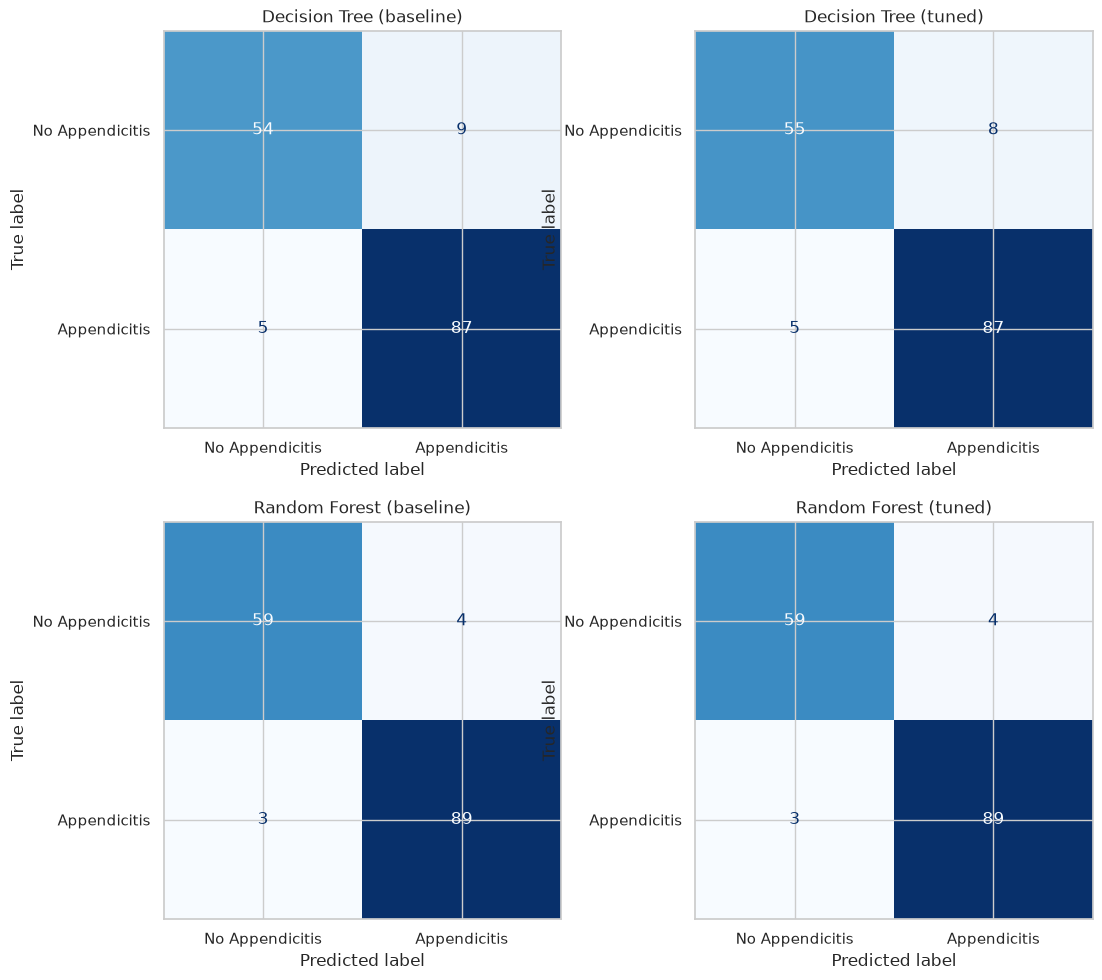

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Appendicitis", "Appendicitis"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [43]:
# Same info as a table, with FN highlighted since it's the clinically costliest error
cm_summary = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cm_summary.append({
        "model": name, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "FN_rate": fn / (fn + tp)   # fraction of actual appendicitis cases missed
    })

pd.DataFrame(cm_summary)

,model,TN,FP,FN,TP,FN_rate
0,Decision Tree (baseline),54,9,5,87,0.054348
1,Decision Tree (tuned),55,8,5,87,0.054348
2,Random Forest (baseline),59,4,3,89,0.032609
3,Random Forest (tuned),59,4,3,89,0.032609
4,XGBoost (baseline),58,5,2,90,0.021739
5,XGBoost (tuned),59,4,2,90,0.021739
6,LightGBM (baseline),59,4,3,89,0.032609
7,LightGBM (tuned),59,4,4,88,0.043478


## Feature Importance — Decision Tree, Random Forest, XGBoost

Each of these models computes feature importance differently, so the numbers aren't
directly comparable across models in an absolute sense -- but the *relative ranking*
of top features is usually informative and worth comparing.

- Decision Tree / Random Forest: importance is based on total reduction in impurity
  (Gini by default) each feature contributes across all splits where it's used,
  weighted by how many samples reach that split. Features used in splits near the
  root (affecting more samples) tend to dominate.

- XGBoost: several importance types available (we'll use "gain" -- average
  improvement in the loss function brought by splits using that feature, generally
  considered the most informative of XGBoost's options, more so than "weight"
  which just counts how often a feature is used for splitting).

A known limitation worth keeping in mind: impurity/gain-based importance can be
biased toward high-cardinality or continuous features (more possible split points
to exploit), so treat this as informative, not definitive -- SHAP values are a more
rigorous alternative if your group wants to go deeper later.

In [43]:
def get_importance_df(model, feature_names, model_name, importance_type=None):
    if importance_type == "gain":  # XGBoost
        importances = model.get_booster().get_score(importance_type="gain")
        imp_df = pd.DataFrame({
            "feature": list(importances.keys()),
            "importance": list(importances.values())
        })
    else:  # sklearn-style (Decision Tree, Random Forest)
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        })
    imp_df["model"] = model_name
    return imp_df.sort_values("importance", ascending=False)

In [44]:
imp_dt = get_importance_df(best_dt, X_train.columns, "Decision Tree")
imp_rf = get_importance_df(best_rf, X_train.columns, "Random Forest")
imp_xgb = get_importance_df(best_xgb, X_train.columns, "XGBoost", importance_type="gain")

# Top 15 features for each
print("Decision Tree - Top 15")
display(imp_dt.head(15))

print("\nRandom Forest - Top 15")
display(imp_rf.head(15))

print("\nXGBoost - Top 15")
display(imp_xgb.head(15))

Decision Tree - Top 15


,feature,importance,model
9,Appendix_Diameter,0.457042,Decision Tree
5,Length_of_Stay,0.146829,Decision Tree
8,Appendix_on_US,0.078338,Decision Tree
17,WBC_Count,0.062526,Decision Tree
6,Alvarado_Score,0.055137,Decision Tree
68,Ipsilateral_Rebound_Tenderness_observed,0.034283,Decision Tree
3,Height,0.026030,Decision Tree
32,Ipsilateral_Rebound_Tenderness,0.025500,Decision Tree
7,Paedriatic_Appendicitis_Score,0.023912,Decision Tree
28,CRP,0.019290,Decision Tree



Random Forest - Top 15


,feature,importance,model
9,Appendix_Diameter,0.360207,Random Forest
5,Length_of_Stay,0.139469,Random Forest
8,Appendix_on_US,0.073045,Random Forest
17,WBC_Count,0.048124,Random Forest
32,Ipsilateral_Rebound_Tenderness,0.046369,Random Forest
68,Ipsilateral_Rebound_Tenderness_observed,0.043636,Random Forest
81,Appendix_Diameter_observed,0.039499,Random Forest
6,Alvarado_Score,0.035048,Random Forest
7,Paedriatic_Appendicitis_Score,0.030436,Random Forest
28,CRP,0.025008,Random Forest



XGBoost - Top 15


,feature,importance,model
29,Ipsilateral_Rebound_Tenderness_observed,14.566941,XGBoost
8,Appendix_Diameter,14.346242,XGBoost
24,Appendix_Wall_Layers,12.093074,XGBoost
22,Ipsilateral_Rebound_Tenderness,11.717108,XGBoost
25,Surrounding_Tissue_Reaction,8.764121,XGBoost
7,Appendix_on_US,8.510601,XGBoost
4,Length_of_Stay,7.992338,XGBoost
31,Appendix_Diameter_observed,6.192073,XGBoost
5,Alvarado_Score,4.962667,XGBoost
6,Paedriatic_Appendicitis_Score,2.970545,XGBoost


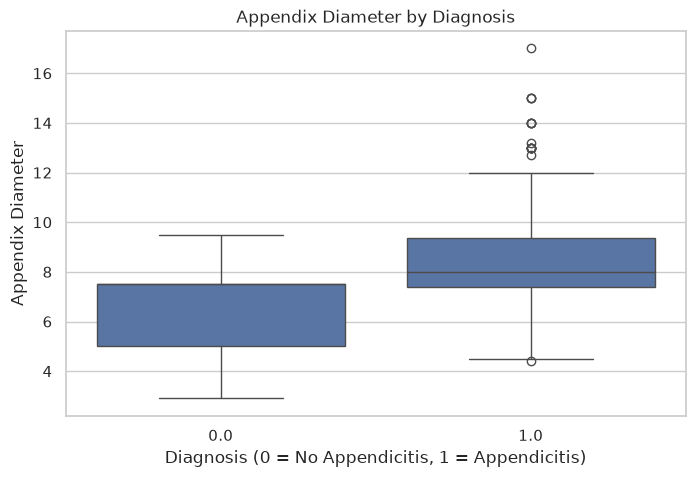

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=y_train, y=X_train["Appendix_Diameter"])
plt.xlabel("Diagnosis (0 = No Appendicitis, 1 = Appendicitis)")
plt.ylabel("Appendix Diameter")
plt.title("Appendix Diameter by Diagnosis")
plt.show()

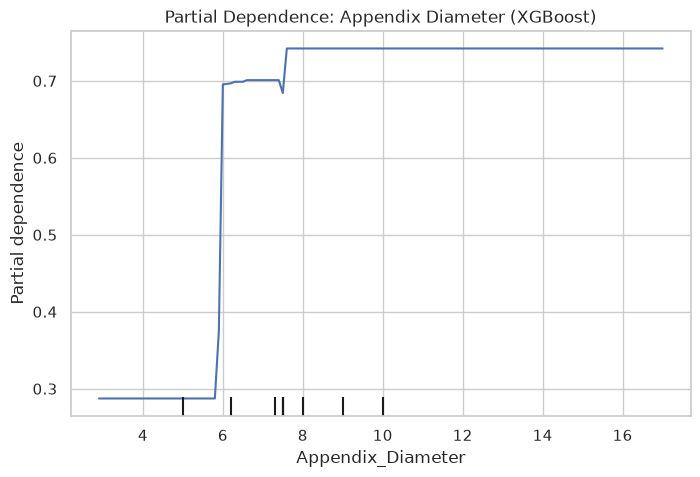

In [46]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_train, features=["Appendix_Diameter"], ax=ax
)
plt.title("Partial Dependence: Appendix Diameter (XGBoost)")
plt.show()

In [47]:
from sklearn.tree import export_text

tree_rules = export_text(best_dt, feature_names=list(X_train.columns), max_depth=3)
print(tree_rules)

|--- Appendix_Diameter <= 7.55
|   |--- Length_of_Stay <= 3.50
|   |   |--- Appendix_on_US <= 0.50
|   |   |   |--- Ipsilateral_Rebound_Tenderness <= -0.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- Ipsilateral_Rebound_Tenderness >  -0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Appendix_on_US >  0.50
|   |   |   |--- Appendix_Diameter <= 5.95
|   |   |   |   |--- class: 0.0
|   |   |   |--- Appendix_Diameter >  5.95
|   |   |   |   |--- truncated branch of depth 4
|   |--- Length_of_Stay >  3.50
|   |   |--- WBC_Count <= 11.35
|   |   |   |--- Ipsilateral_Rebound_Tenderness_observed <= 0.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- Ipsilateral_Rebound_Tenderness_observed >  0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- WBC_Count >  11.35
|   |   |   |--- Appendix_Diameter <= 4.00
|   |   |   |   |--- class: 0.0
|   |   |   |--- Appendix_Diameter >  4.00
|   |   |   |   |--- truncated branch of depth 6
|--- Appendix_Diameter >  7.5

## Investigating the False Negatives

For a diagnostic task, understanding *why* the model missed a case
matters more than the aggregate metric. Let's identify exactly which test patients
were false negatives (actual = appendicitis, predicted = no appendicitis), then look
at three things:

1. How confident was the model in its (wrong) prediction? (predict_proba)
2. How do their feature values compare to the typical appendicitis patient?
3. How much would a key feature need to change to flip the prediction?

We'll use XGBoost (tuned) since it was the best-performing model on the test set.

In [48]:
# Get predictions and probabilities on the test set
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Identify false negatives: actual = 1, predicted = 0
fn_mask = (y_test.values == 1) & (y_pred_xgb == 0)
fn_indices = X_test.index[fn_mask]

print(f"Number of false negatives: {fn_mask.sum()}")
print(f"Test set indices: {list(fn_indices)}")

# Show their predicted probability (how close to the 0.5 threshold were they?)
fn_details = pd.DataFrame({
    "true_label": y_test[fn_mask].values,
    "predicted_label": y_pred_xgb[fn_mask],
    "predicted_probability": y_proba_xgb[fn_mask]
}, index=fn_indices)

fn_details

Number of false negatives: 2
Test set indices: [593, 656]


,true_label,predicted_label,predicted_probability
593,1.0,0,0.028802
656,1.0,0,0.080500


## Comparing false negatives to typical appendicitis patients

Let's pull the top important features (from earlier) and compare these two patients'
actual values against the distribution of correctly-identified appendicitis patients
in the training set to spot which values look "atypical" for a positive case.

In [49]:
# Top features from XGBoost importance (reuse imp_xgb from before)
top_features = imp_xgb.head(10)["feature"].tolist()

# Reference: feature distributions for actual appendicitis patients in training data
positive_train = X_train[y_train == 1]

# Build a comparison table: FN patient values vs. typical positive patient stats
comparison_rows = []
for feat in top_features:
    row = {"feature": feat}
    for idx in fn_indices:
        row[f"patient_{idx}"] = X_test.loc[idx, feat]
    row["positive_median"] = positive_train[feat].median()
    row["positive_mean"] = positive_train[feat].mean()
    comparison_rows.append(row)

fn_vs_typical = pd.DataFrame(comparison_rows)
fn_vs_typical

,feature,patient_593,patient_656,positive_median,positive_mean
0,Ipsilateral_Rebound_Tenderness_observed,1.0,1.0,1.0,0.661202
1,Appendix_Diameter,7.5,5.0,8.0,8.456284
2,Appendix_Wall_Layers,-1.0,-1.0,-1.0,-0.401639
3,Ipsilateral_Rebound_Tenderness,0.0,0.0,0.0,-0.275956
4,Surrounding_Tissue_Reaction,-1.0,-1.0,-1.0,-0.109290
5,Appendix_on_US,0.0,1.0,1.0,0.814208
6,Length_of_Stay,3.0,4.0,4.0,5.114754
7,Appendix_Diameter_observed,0.0,1.0,1.0,0.806011
8,Alvarado_Score,7.0,4.0,7.0,6.636612
9,Paedriatic_Appendicitis_Score,5.0,4.0,6.0,5.838798


## How much would a value need to change to flip the prediction?

This is a counterfactual question: for the single most important feature
(Appendix_Diameter), how far off is this patient from the model's decision boundary?
We'll take one false-negative patient and sweep Appendix_Diameter across a range,
holding everything else fixed, to see at what value the model's prediction flips
from 0 to 1.

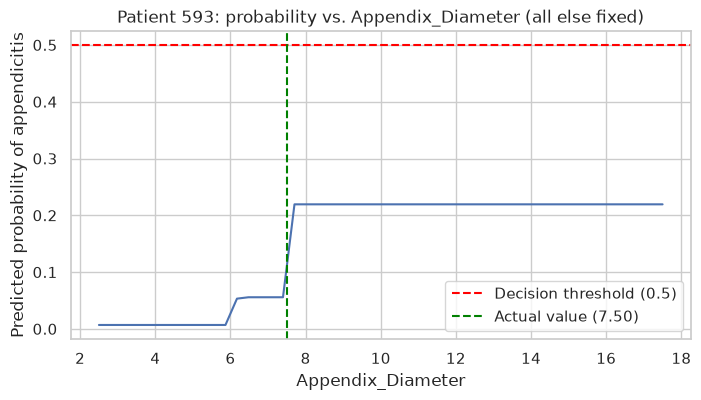

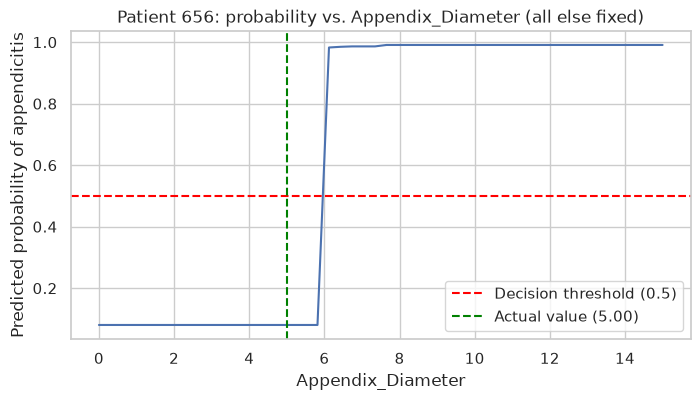

In [50]:
def find_flip_point(model, patient_row, feature, value_range):
    results = []
    for val in value_range:
        modified = patient_row.copy()
        modified[feature] = val
        proba = model.predict_proba(modified.values.reshape(1, -1))[0, 1]
        results.append({feature: val, "predicted_probability": proba})
    return pd.DataFrame(results)

# Run this for each false negative patient
for idx in fn_indices:
    patient = X_test.loc[idx]
    actual_value = patient["Appendix_Diameter"]
    
    # Sweep a reasonable range around the actual value
    value_range = np.linspace(actual_value - 5, actual_value + 10, 50)
    flip_df = find_flip_point(best_xgb, patient, "Appendix_Diameter", value_range)
    
    plt.figure(figsize=(8, 4))
    plt.plot(flip_df["Appendix_Diameter"], flip_df["predicted_probability"])
    plt.axhline(0.5, color="red", linestyle="--", label="Decision threshold (0.5)")
    plt.axvline(actual_value, color="green", linestyle="--", label=f"Actual value ({actual_value:.2f})")
    plt.xlabel("Appendix_Diameter")
    plt.ylabel("Predicted probability of appendicitis")
    plt.title(f"Patient {idx}: probability vs. Appendix_Diameter (all else fixed)")
    plt.legend()
    plt.show()

In [51]:
patient_593 = X_test.loc[593]

print("Patient 593 - key values:")
print(f"  Appendix_Diameter: {patient_593['Appendix_Diameter']}")
print(f"  Appendix_Diameter_observed: {patient_593['Appendix_Diameter_observed']}")
print(f"  Current predicted probability: {best_xgb.predict_proba(patient_593.values.reshape(1, -1))[0, 1]:.4f}")

Patient 593 - key values:
  Appendix_Diameter: 7.5
  Appendix_Diameter_observed: 0.0
  Current predicted probability: 0.0288


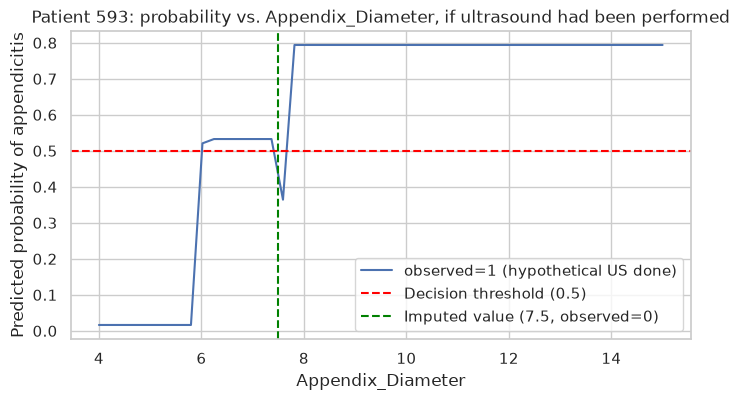

In [52]:
# Counterfactual: what if the ultrasound HAD been performed, across a range of diameters?
value_range = np.linspace(4, 15, 50)
results = []

for val in value_range:
    modified = patient_593.copy()
    modified["Appendix_Diameter"] = val
    modified["Appendix_Diameter_observed"] = 1.0   # simulate that ultrasound WAS done
    proba = best_xgb.predict_proba(modified.values.reshape(1, -1))[0, 1]
    results.append({"Appendix_Diameter": val, "predicted_probability": proba})

flip_df_593 = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.plot(flip_df_593["Appendix_Diameter"], flip_df_593["predicted_probability"], label="observed=1 (hypothetical US done)")
plt.axhline(0.5, color="red", linestyle="--", label="Decision threshold (0.5)")
plt.axvline(7.5, color="green", linestyle="--", label="Imputed value (7.5, observed=0)")
plt.xlabel("Appendix_Diameter")
plt.ylabel("Predicted probability of appendicitis")
plt.title("Patient 593: probability vs. Appendix_Diameter, if ultrasound had been performed")
plt.legend()
plt.show()

In [53]:
# Compare directly: current (unobserved, median-imputed) vs. best-case observed scenario
proba_current = best_xgb.predict_proba(patient_593.values.reshape(1, -1))[0, 1]

modified_observed = patient_593.copy()
modified_observed["Appendix_Diameter_observed"] = 1.0
proba_if_observed_same_value = best_xgb.predict_proba(modified_observed.values.reshape(1, -1))[0, 1]

print(f"Current (observed=0, diameter=7.5 [imputed]):  {proba_current:.4f}")
print(f"Same diameter, but observed=1:                  {proba_if_observed_same_value:.4f}")

Current (observed=0, diameter=7.5 [imputed]):  0.0288
Same diameter, but observed=1:                  0.3644


## What this means for your report

If flipping `Appendix_Diameter_observed` from 0 to 1 (even keeping the same imputed
diameter number) meaningfully raises the probability, that confirms your hypothesis:
the model has learned that "no ultrasound was performed" is itself a signal correlated
with lower appendicitis likelihood in the training data -- plausibly because clinicians
are less likely to order an ultrasound when their clinical suspicion is already low,
which is a form of **missingness that depends on the (unobserved) outcome-related
clinical judgment**, not random missingness. This is worth naming explicitly: it's a
case of MNAR (missing not at random) interacting with model predictions in a clinically
important way -- exactly the kind of scenario your MNAR analysis during preprocessing
was meant to flag.

Practical implication: if patient 593 genuinely had appendicitis but wasn't sent for
ultrasound (maybe based on an atypical presentation, or resource/timing constraints),
your model inherited that same blind spot from the training data. This isn't a flaw
in your modeling choices -- it's a real limitation of the underlying clinical data
collection process, and it's a genuinely interesting and citable finding for your
discussion section (models trained on real-world clinical data can inherit the biases
of clinical decision-making, e.g. who gets tested).

In [54]:
# Check predicted probabilities for ALL false negatives, across all 4 models
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fn_mask = (y_test.values == 1) & (y_pred == 0)
    
    if fn_mask.sum() > 0:
        print(f"\n{name} -- {fn_mask.sum()} false negative(s):")
        print(pd.DataFrame({
            "index": X_test.index[fn_mask],
            "predicted_probability": y_proba[fn_mask]
        }).to_string(index=False))
    else:
        print(f"\n{name} -- 0 false negatives")


Decision Tree (tuned) -- 5 false negative(s):
 index  predicted_probability
   593               0.007692
   565               0.000000
   656               0.000000
   687               0.000000
   731               0.000000

Random Forest (tuned) -- 3 false negative(s):
 index  predicted_probability
   593               0.039437
   656               0.132394
   687               0.498592

XGBoost (tuned) -- 2 false negative(s):
 index  predicted_probability
   593               0.028802
   656               0.080500

LightGBM (tuned) -- 4 false negative(s):
 index  predicted_probability
   593               0.023101
   656               0.047257
   687               0.215554
   731               0.461310


## Interpreting the false-negative probabilities across models

This is a really informative picture. Patients 593 and 656 are consistently missed
by ALL four models, with consistently low probabilities -- strong evidence that
these two are genuinely hard/atypical cases (confirming what we found for 593:
missing ultrasound), not an artifact of one particular model's decision boundary.

But look at patient 687:
- Decision Tree: proba = 0.000 (confidently wrong)
- LightGBM: proba = 0.216 (wrong, but not confident)
- Random Forest: proba = 0.499 -- essentially ON the threshold, missed by a hair
- XGBoost: not a false negative at all -- correctly caught

And patient 731:
- Decision Tree: proba = 0.000
- LightGBM: proba = 0.461 -- close to the threshold
- Random Forest & XGBoost: correctly caught

So patient 687 for Random Forest is exactly the "rescuable" case we were looking for
-- a probability of 0.499 means an almost negligible threshold drop (e.g. to 0.49)
would flip it to correctly predicted. This is very different from patients 593/656,
where even a drastic threshold drop wouldn't help without sweeping in many false
positives.

## Precision-recall tradeoff across thresholds

Regardless of what the individual FN probabilities show, this gives the full picture:
how does recall improve (and precision degrade) as we lower the threshold below 0.5,
for each model?

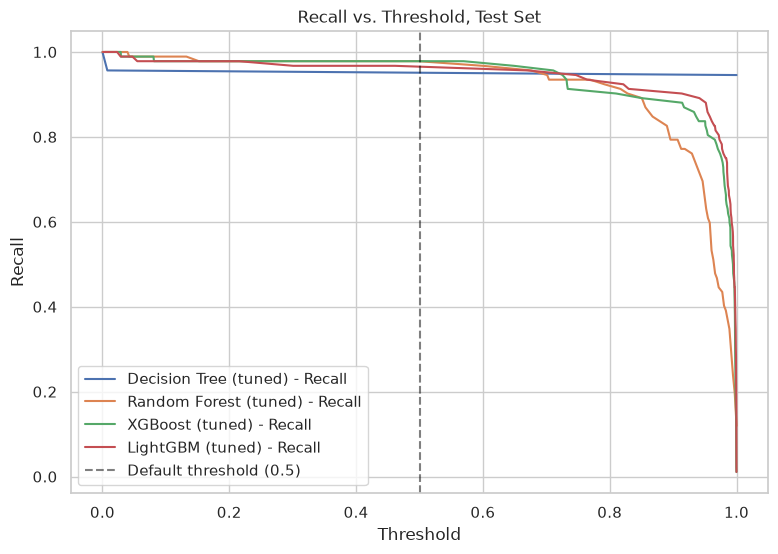

In [55]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    ax.plot(thresholds, recall[:-1], label=f"{name} - Recall")

ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Default threshold (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Recall")
ax.set_title("Recall vs. Threshold, Test Set")
ax.legend()
plt.show()

In [56]:
# Concretely: what recall/precision do we get at a few candidate thresholds?
candidate_thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_results = []
for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    for t in candidate_thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        threshold_results.append({
            "model": name,
            "threshold": t,
            "recall": recall_score(y_test, y_pred_t),
            "precision": precision_score(y_test, y_pred_t),
            "f1": f1_score(y_test, y_pred_t)
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.pivot_table(index="threshold", columns="model", values=["recall", "precision"])

precision                                         \
model     Decision Tree (tuned) LightGBM (tuned) Random Forest (tuned)   
threshold                                                                
0.1                    0.915789         0.900000              0.819820   
0.2                    0.915789         0.918367              0.865385   
0.3                    0.915789         0.927083              0.918367   
0.4                    0.915789         0.946809              0.947368   
0.5                    0.915789         0.956522              0.956989   

                                         recall                   \
model     XGBoost (tuned) Decision Tree (tuned) LightGBM (tuned)   
threshold                                                          
0.1              0.849057              0.945652         0.978261   
0.2              0.927835              0.945652         0.978261   
0.3              0.937500              0.945652         0.967391   
0.4              0.957447              0.945652         0.967391   
0.5              0.957447              0.945652         0.956522   

                                                 
model     Random Forest (tuned) XGBoost (tuned)  
threshold                                        
0.1                    0.989130        0.978261  
0.2                    0.978261        0.978261  
0.3                    0.978261        0.978261  
0.4                    0.978261        0.978261  
0.5                    0.967391        0.978261

## How each model computes predicted probability

Worth understanding, since we've been leaning heavily on `predict_proba` for the
false-negative analysis and threshold tuning -- these numbers aren't computed the
same way across models, which matters for how much you trust/interpret them.

---

### Decision Tree

A single tree's probability is the simplest of the four: it's just the **class
frequency at the leaf node** a sample lands in.

When the tree is built, each leaf ends up containing some subset of training samples
(e.g. after all the splits, 12 training patients land in a particular leaf: 10 with
Diagnosis=1, 2 with Diagnosis=0). For any new patient routed to that same leaf, the
predicted probability is:

$$P(\text{class}=1) = \frac{n_{\text{class 1 in leaf}}}{n_{\text{total in leaf}}}$$

In the example above: 10/12 = 0.833.

**Why this explains what we saw for patient 593/656/687/731 with Decision Tree**:
several of their leaves apparently contained ZERO training patients with Diagnosis=1
(hence proba = exactly 0.000). This is a known weakness of single trees -- probability
estimates from small leaves are extreme (0 or 1) and poorly calibrated, since they're
based on very few samples. This is one more reason Random Forest tends to give more
trustworthy probabilities than a single tree.

---

### Random Forest

Random Forest averages the leaf-based probability (as computed above) across all
individual trees in the forest:

$$P(\text{class}=1) = \frac{1}{n_{\text{trees}}} \sum_{i=1}^{n_{\text{trees}}} P_i(\text{class}=1)$$

where $P_i$ is the leaf-probability estimate from tree $i$ (same calculation as a
single Decision Tree, just repeated for each of the ~355 trees in your tuned forest,
each trained on a different bootstrap sample with a random feature subset per split).

This is why Random Forest's probabilities are much smoother/more continuous than a
single tree's (e.g. patient 687's 0.499 instead of a stark 0/1) -- averaging over
hundreds of trees, each with slightly different splits and leaf compositions, produces
a much finer-grained probability estimate rather than a handful of possible leaf ratios.

---

### XGBoost

Gradient boosting works fundamentally differently -- it doesn't average class
frequencies. Instead, each tree outputs a **raw score** (not a probability), and
these scores are added up sequentially across all trees, then converted to a
probability at the very end via the **sigmoid function**.

Step by step:
1. Start with an initial base prediction (a raw score, often 0 or the log-odds of
   the base rate).
2. Each subsequent tree predicts a raw score adjustment (not a class!) that reduces
   the ensemble's current errors (technically: fits the negative gradient of the
   loss function -- for binary classification with log-loss, this gradient relates
   to the residual between the true label and current predicted probability).
3. These per-tree score adjustments are summed, scaled by `learning_rate`:
   $$z = z_0 + \eta \sum_{i=1}^{n_{\text{trees}}} f_i(x)$$
   where $z_0$ is the base score, $\eta$ is the learning rate, and $f_i(x)$ is tree
   $i$'s raw output for input $x$.
4. Finally, the summed raw score $z$ is passed through the sigmoid function to get
   a probability:
   $$P(\text{class}=1) = \frac{1}{1 + e^{-z}}$$

So XGBoost's probability isn't "what fraction of similar training examples were
positive" (like the tree-averaging approach) -- it's "how strongly, in total, did
every tree's sequential correction push the raw score toward positive," squashed
into a 0-1 range at the end. This tends to produce well-separated, confident
probabilities near 0 or 1 when the ensemble strongly agrees across many boosting
rounds -- which matches what we saw for patients 593/656 (very low, ~0.03-0.08,
reflecting that many sequential trees consistently pushed the raw score negative).

---

### LightGBM

Conceptually identical to XGBoost -- it's also gradient boosting, so the same
raw-score-summed-then-sigmoid process applies:

$$P(\text{class}=1) = \frac{1}{1 + e^{-z}}, \quad z = z_0 + \eta \sum_{i=1}^{n_{\text{trees}}} f_i(x)$$

The difference from XGBoost isn't in *how the probability formula works* -- it's in
*how each $f_i(x)$ (each tree's raw score contribution) gets computed*, because of
LightGBM's leaf-wise growth strategy (fewer, more targeted splits per tree, as we
discussed earlier) versus XGBoost's level-wise growth. Different tree-building
strategy, same final aggregation-and-sigmoid mechanism for turning scores into
probabilities.

---

### Key practical takeaway

- **Tree-averaging models (Decision Tree, Random Forest)**: probability = observed
  class frequency in similar training examples. Can be poorly calibrated for single
  trees (extreme 0/1 values from small leaves), better for Random Forest (averaging
  smooths this out).
- **Boosting models (XGBoost, LightGBM)**: probability = sigmoid of an additively
  built raw score, not a direct frequency count. Tends to produce more confidently
  separated probabilities, since many small sequential corrections compound.

This is also *why* threshold tuning and probability-based diagnostics (like we just
did for the false negatives) are meaningful operations at all -- these aren't
arbitrary numbers, they reflect genuinely different underlying computations that
each carry real information about how the model reached its decision.

## Appendix: Gradient Boosting — Loss Function, Gradients & Hessians

### The loss function

XGBoost/LightGBM use binary log-loss (binary cross-entropy) — the same loss as logistic regression:

$$L(y, \hat{p}) = -\left[y \log(\hat{p}) + (1-y)\log(1-\hat{p})\right]$$

where $y \in \{0, 1\}$ is the true label and $\hat{p} = \sigma(z) = \dfrac{1}{1+e^{-z}}$ is the predicted probability (sigmoid of the raw score $z$).

The full training objective sums this over all $n$ samples, plus a regularization term on tree complexity:

$$\mathcal{L} = \sum_{j=1}^{n} L(y_j, \hat{p}_j) + \Omega(\text{trees})$$

$\Omega$ penalizes leaf count and leaf-weight magnitude (controlled by `gamma`, `reg_alpha`, `reg_lambda`).

### Gradient and Hessian

Each new tree is fit using a second-order Taylor expansion of the loss — using both the first derivative (gradient) and second derivative (Hessian) with respect to the current prediction. This is "Newton boosting": using curvature, not just slope, to take a better step.

For sample $j$ at boosting round $t$, with current predicted probability $\hat{p}_j^{(t-1)}$:

**Gradient** (residual — how wrong the current prediction is):
$$g_j = \hat{p}_j^{(t-1)} - y_j$$

**Hessian** (how confident/uncertain the current prediction is):
$$h_j = \hat{p}_j^{(t-1)}\left(1 - \hat{p}_j^{(t-1)}\right)$$

$h_j$ is largest (0.25) at $\hat{p}=0.5$ (max uncertainty) and near 0 when $\hat{p}$ is close to 0 or 1 (already confident).

The optimal weight a new leaf should output, for a group of samples in that leaf:

$$w^* = -\frac{\sum_{j \in \text{leaf}} g_j}{\sum_{j \in \text{leaf}} h_j + \lambda}$$

where $\lambda$ is `reg_lambda`. This same quantity (in aggregate form) is also what candidate splits are scored on — not Gini impurity like Decision Tree/Random Forest.

---

### Toy example — computing $g_j$ and $h_j$ by hand

Suppose after round $t{-}1$, the ensemble currently predicts these probabilities for 3 patients:

| Patient | True label $y_j$ | Current $\hat{p}_j$ |
|---|---|---|
| A | 1 (appendicitis) | 0.90 |
| B | 1 (appendicitis) | 0.50 |
| C | 0 (no appendicitis) | 0.20 |

**Step 1 — Gradient** $g_j = \hat{p}_j - y_j$:

- Patient A: $g_A = 0.90 - 1 = -0.10$
- Patient B: $g_B = 0.50 - 1 = -0.50$
- Patient C: $g_C = 0.20 - 0 = \phantom{-}0.20$

**Step 2 — Hessian** $h_j = \hat{p}_j(1-\hat{p}_j)$:

- Patient A: $h_A = 0.90 \times 0.10 = 0.09$
- Patient B: $h_B = 0.50 \times 0.50 = 0.25$
- Patient C: $h_C = 0.20 \times 0.80 = 0.16$

**Interpretation:**
- Patient A: small $|g|$, small $h$ → model is close and confident, little correction needed.
- Patient B: large $|g|$, largest $h$ → model is maximally uncertain AND currently wrong-leaning; this sample will get pushed hardest.
- Patient C: moderate $|g|$, moderate $h$ → some correction needed, less urgently than B.

**Step 3 — Optimal leaf weight**, if all 3 patients land in the same leaf of the next tree (with $\lambda = 1$ for illustration):

$$w^* = -\frac{g_A + g_B + g_C}{h_A + h_B + h_C + \lambda} = -\frac{(-0.10) + (-0.50) + 0.20}{0.09 + 0.25 + 0.16 + 1} = -\frac{-0.40}{1.50} \approx 0.267$$

This positive weight (0.267) gets added to the raw score $z$ for all three patients if they share this leaf — nudging their combined prediction toward class 1, since on net (in gradient terms) this group is under-predicting class 1.

---

*Try it yourself*: pick 3-4 rows from `X_train`/`y_train`, use `best_xgb.predict_proba()` to get their current probabilities, and compute $g_j$/$h_j$ by hand using the formulas above — a good sanity check to confirm you understand what's driving each tree's corrections.